In [1]:
# ============================================================
# CELL 1: Install packages
# ============================================================

# torchmetrics is used later for computing the FID score.
# torch-fidelity provides the Inception network used by TorchMetrics.

!pip install -q torchmetrics[image] torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.3 MB/s eta 0:00:00


In [2]:
# ============================================================
# CELL 2: Import required libraries
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from torchvision.utils import make_grid

import matplotlib.pyplot as plt
import numpy as np

In [3]:
# ============================================================
# CELL 3: Device configuration and random seed
# ============================================================

# Use GPU if available.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Fixing random seeds makes results more reproducible.
torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

Using device: cpu


In [4]:
# ============================================================
# CELL 4: Download and prepare MNIST
# ============================================================

# Generator outputs will use Tanh().
#
# Tanh produces values in the range:
#
#       [-1, 1]
#
# Therefore we also convert the real MNIST images to [-1, 1].
#
# Original ToTensor() range:
#
#       [0, 1]
#
# Normalize(mean=0.5, std=0.5):
#
#       x_new = (x - 0.5) / 0.5
#
# converts:
#
#       0 -> -1
#       1 -> +1

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Number of training images:", len(train_dataset))
print("Number of batches:", len(train_loader))

100%|██████████| 9.91M/9.91M [00:00<00:00, 39.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.03MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.98MB/s]

Number of training images: 60000
Number of batches: 469


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Image batch shape: torch.Size([128, 1, 28, 28])
Label batch shape: torch.Size([128])


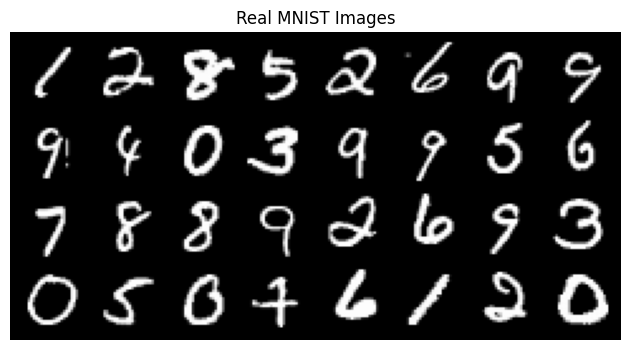

In [5]:
# ============================================================
# CELL 5: Visualize some real MNIST images
# ============================================================

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

# Convert [-1,1] -> [0,1] only for visualization.
images_display = (images + 1) / 2

grid = make_grid(
    images_display[:32],
    nrow=8
)

plt.figure(figsize=(8, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Real MNIST Images")
plt.show()

In [6]:
# ============================================================
# CELL 6: Vanilla GAN hyperparameters
# ============================================================

# Dimension of the random latent vector.
LATENT_DIM = 100

# MNIST images are 28 x 28.
IMAGE_SIZE = 28 * 28

LEARNING_RATE = 0.0002

# 10 is sufficient for a classroom demonstration.
# Increase this to 30-50 for better images.
NUM_EPOCHS = 25

In [7]:
# ============================================================
# CELL 7: Vanilla GAN Generator
# ============================================================

class VanillaGenerator(nn.Module):

    def __init__(self, latent_dim=100):
        super().__init__()

        # Input:
        #       random noise z
        #       shape = [batch_size, latent_dim]
        #
        # Output:
        #       flattened MNIST image
        #       shape = [batch_size, 784]

        self.model = nn.Sequential(

            # 100 -> 256
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),

            # 256 -> 512
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),

            # 512 -> 1024
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),

            # 1024 -> 784
            nn.Linear(1024, 28 * 28),

            # Output pixels in [-1, 1]
            nn.Tanh()
        )

    def forward(self, z):

        # Pass random noise through the neural network.
        img = self.model(z)

        return img

In [8]:
# ============================================================
# CELL 8: Vanilla GAN Discriminator
# ============================================================

class VanillaDiscriminator(nn.Module):

    def __init__(self):
        super().__init__()

        # Input:
        #       flattened MNIST image
        #       28 x 28 = 784
        #
        # Output:
        #       ONE logit
        #
        # Positive logit -> probably real
        # Negative logit -> probably fake

        self.model = nn.Sequential(

            nn.Linear(28 * 28, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1)

            # IMPORTANT:
            # We DO NOT place Sigmoid here.
            #
            # BCEWithLogitsLoss automatically applies the
            # sigmoid operation internally.
        )

    def forward(self, img):

        return self.model(img)

In [9]:
# ============================================================
# CELL 9: Create Vanilla GAN
# ============================================================

vanilla_G = VanillaGenerator(
    latent_dim=LATENT_DIM
).to(device)

vanilla_D = VanillaDiscriminator().to(device)

print(vanilla_G)
print()

print(vanilla_D)

VanillaGenerator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)

VanillaDiscriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=1, bias=True)
  )
)


In [10]:
# ============================================================
# CELL 10: Loss function and optimizers
# ============================================================

# Binary classification:
#
# Real -> 1
# Fake -> 0

criterion = nn.BCEWithLogitsLoss()


# Generator optimizer
optimizer_G = optim.Adam(
    vanilla_G.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)


# Discriminator optimizer
optimizer_D = optim.Adam(
    vanilla_D.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

In [ ]:
# ============================================================
# CELL 11: Train Vanilla GAN
# ============================================================

vanilla_G.train()
vanilla_D.train()

for epoch in range(NUM_EPOCHS):

    running_d_loss = 0
    running_g_loss = 0

    for real_images, _ in train_loader:

        # ----------------------------------------------------
        # Prepare real images
        # ----------------------------------------------------

        batch_size = real_images.size(0)

        # Move images to GPU/CPU.
        real_images = real_images.to(device)

        # Vanilla GAN uses fully-connected layers.
        # Therefore flatten:
        #
        # [B, 1, 28, 28]
        #
        # becomes
        #
        # [B, 784]

        real_images = real_images.view(batch_size, -1)


        # ====================================================
        # STEP 1: TRAIN THE DISCRIMINATOR
        # ====================================================

        optimizer_D.zero_grad()


        # ----------------------------------------------------
        # Discriminator on REAL images
        # ----------------------------------------------------

        real_output = vanilla_D(real_images)

        # Real images should have target = 1.
        real_targets = torch.ones(
            batch_size,
            1,
            device=device
        )

        loss_real = criterion(
            real_output,
            real_targets
        )


        # ----------------------------------------------------
        # Generate FAKE images
        # ----------------------------------------------------

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            device=device
        )

        fake_images = vanilla_G(noise)


        # ----------------------------------------------------
        # Discriminator on FAKE images
        # ----------------------------------------------------

        # detach() prevents gradients flowing into G
        # while D is being trained.

        fake_output = vanilla_D(
            fake_images.detach()
        )

        # Fake images should have target = 0.
        fake_targets = torch.zeros(
            batch_size,
            1,
            device=device
        )

        loss_fake = criterion(
            fake_output,
            fake_targets
        )


        # Total discriminator loss
        d_loss = loss_real + loss_fake

        d_loss.backward()

        optimizer_D.step()


        # ====================================================
        # STEP 2: TRAIN THE GENERATOR
        # ====================================================

        optimizer_G.zero_grad()


        # Generator wants discriminator to believe
        # generated images are REAL.
        #
        # Therefore target = 1.

        fake_output = vanilla_D(fake_images)

        g_targets = torch.ones(
            batch_size,
            1,
            device=device
        )

        g_loss = criterion(
            fake_output,
            g_targets
        )

        g_loss.backward()

        optimizer_G.step()


        running_d_loss += d_loss.item()
        running_g_loss += g_loss.item()


    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"D Loss: {running_d_loss/len(train_loader):.4f} "
        f"G Loss: {running_g_loss/len(train_loader):.4f}"
    )

Epoch [1/25] D Loss: 1.2049 G Loss: 0.9340


In [ ]:
# ============================================================
# CELL 12: Generate MNIST digits using Vanilla GAN
# ============================================================

vanilla_G.eval()

with torch.no_grad():

    # Generate 32 random latent vectors.
    noise = torch.randn(
        32,
        LATENT_DIM,
        device=device
    )

    generated_images = vanilla_G(noise)

    # Convert:
    #
    # [32, 784]
    #
    # to
    #
    # [32, 1, 28, 28]

    generated_images = generated_images.view(
        -1, 1, 28, 28
    )

    # Convert from [-1,1] to [0,1].
    generated_images = (
        generated_images + 1
    ) / 2


grid = make_grid(
    generated_images.cpu(),
    nrow=8
)

plt.figure(figsize=(8, 4))

plt.imshow(
    grid.permute(1, 2, 0)
)

plt.axis("off")

plt.title("Images Generated by Vanilla GAN")

plt.show()